# 🏠 Desenvolvimento de IA para Análise Preditiva de uma Imobiliária

## 💼 Declaração do Problema de Negócio

* **🔍 O Problema**: Uma imobiliária do condado de King County (EUA) deseja estimar de forma assertiva o valor de venda de um imóvel com base em suas características físicas e geográficas.
* **🎯 Variável-Alvo**: `price` (Preço, valor numérico contínuo em dólares).
* **💰 Importância para o Negócio**: Mitigar estimativas equivocadas e prejuízos financeiros. Uma precificação correta apoia decisões seguras de compra, venda ou financiamento imobiliário, otimizando as margens do portfólio.

In [1]:
# Autor: Paulo A. N. Cordeiro
# Data.: Julho/2026
# Cria a configuração das pastas (se não existir) e os path do sistema
# Para ver as configurações acesse o src/config.py
import sys
import importlib
import warnings
import os
from IPython.utils import io

# Suprime avisos e alertas de bibliotecas
warnings.filterwarnings('ignore')

# Correção (Patch) para o erro do 'imp' nas versões novas do Python
if 'imp' not in sys.modules:
    sys.modules['imp'] = importlib

# Execução silenciosa (Captura os outputs ruidosos do Drive e Autoreload)
with io.capture_output():
    %load_ext autoreload
    %autoreload 2
    from google.colab import drive
    # Verifica se já está montado para evitar a mensagem de re-montagem
    if not os.path.exists('/content/drive/MyDrive'):
        drive.mount('/content/drive')

# Configuração de diretórios
# BASE_DIR necessário aqui só pra arranque do sistema, o que vale para
# produção está no src/config.py
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/Projeto Final/Projeto_Final_V1"
os.makedirs(os.path.join(BASE_DIR, "src/modeling"), exist_ok=True)
os.chdir(BASE_DIR)

if '.' not in sys.path:
    sys.path.insert(0, '.')

# Importação dos módulos
from src import config
from src.dataset import carregar_dados, obter_estatisticas_basicas, limpar_dados
from src.plots import plotar_analise_exploratoria, plotar_avaliacao_modelo, plotar_boxplots_outliers, plotar_histograma_preco, plotar_dispersao_area_preco, plotar_dispersao_qualidade_preco, plotar_mapa_correlacao
from src.features import criar_novas_features, preparar_dados_modelagem, calcular_vif
from src.modeling.train import treinar_e_avaliar_modelo

# Garante fisicamente a criação de todas as pastas listadas no config.py
for pasta in config.DIRETORIOS_NECESSARIOS:
    os.makedirs(pasta, exist_ok=True)

print("✔ Ambiente configurado e módulos carregados com sucesso!")

✔ Ambiente configurado e módulos carregados com sucesso!


## Fase 1: Análise Exploratória de Dados (EDA)
Execução da estatística descritiva estruturada para compreender as dimensões, tipos de dados primitivos e a distribuição geral do dataset.

In [2]:
# 1. Carga dos dados brutos
df_bruto = carregar_dados()

# 2. Extração das propriedades estatísticas descritivas obrigatórias
dim, tipos, resumo = obter_estatisticas_basicas(df_bruto)

print(f"Dimensões do Dataset: {dim[0]} linhas e {dim[1]} colunas.\n")
print("=== TIPOS PRIMITIVOS DAS VARIÁVEIS ===")
print(tipos)
print("\n=== RESUMO ESTATÍSTICO DESCRITIVO ===")
display(resumo.T)

Dimensões do Dataset: 21613 linhas e 21 colunas.

=== TIPOS PRIMITIVOS DAS VARIÁVEIS ===
id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above       float64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

=== RESUMO ESTATÍSTICO DESCRITIVO ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,21613.0,NaN,NaN,NaN,4580301520.864988,2876565571.312049,1000102.0,2123049194.0,3904930410.0,7308900445.0,9900000190.0
date,21613,372,20140623T000000,142,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,21613.0,NaN,NaN,NaN,540088.141767,367127.196483,75000.0,321950.0,450000.0,645000.0,7700000.0
bedrooms,21613.0,NaN,NaN,NaN,3.370842,0.930062,0.0,3.0,3.0,4.0,33.0
bathrooms,21613.0,NaN,NaN,NaN,2.114757,0.770163,0.0,1.75,2.25,2.5,8.0
sqft_living,21613.0,NaN,NaN,NaN,2079.899736,918.440897,290.0,1427.0,1910.0,2550.0,13540.0
sqft_lot,21613.0,NaN,NaN,NaN,15106.967566,41420.511515,520.0,5040.0,7618.0,10688.0,1651359.0
floors,21613.0,NaN,NaN,NaN,1.494309,0.539989,1.0,1.0,1.5,2.0,3.5
waterfront,21613.0,NaN,NaN,NaN,0.007542,0.086517,0.0,0.0,0.0,0.0,1.0
view,21613.0,NaN,NaN,NaN,0.234303,0.766318,0.0,0.0,0.0,0.0,4.0


### Visualizações Analíticas dos Dados da Fase 1 (EDA)

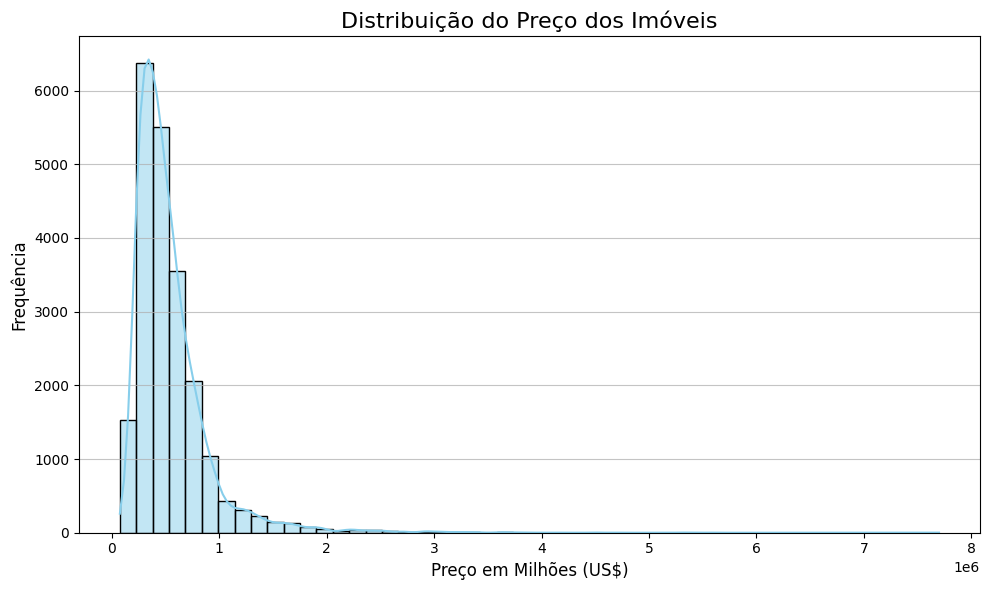

In [3]:
# Análise Exploratória (Histograma de Preços) A função gera o
# gráfico na tela e salva automaticamente na pasta outputs/figures/
plotar_analise_exploratoria(df_bruto)

#### Distribuição da Variável-Alvo (`price`): Assimetria e Impacto

*   **Achado**: O histograma de `price` revelou uma **assimetria positiva acentuada** (cauda longa à direita). A maioria dos imóveis concentra-se em faixas de preço mais baixas, com um número menor de propriedades de alto valor que puxam a média para cima. Isso é comum em mercados imobiliários.
*   **Crítica e Implicação**: Essa distribuição não-normal, especialmente assimétrica, é uma violação da suposição de normalidade dos resíduos (erros) em modelos de regressão linear. Modelos lineares tradicionais podem ter seu desempenho e interpretação comprometidos.
    *   **Escolha de Modelagem**: Será crucial considerar a **transformação logarítmica** da variável `price` (e talvez de algumas variáveis preditoras) para mitigar a assimetria e aproximar a distribuição da normalidade. Isso pode estabilizar a variância dos erros e melhorar o ajuste do modelo, além de tornar os erros mais gaussianos. Alternativamente, modelos não-lineares ou robustos a distribuições não-normais podem ser mais adequados sem transformação.

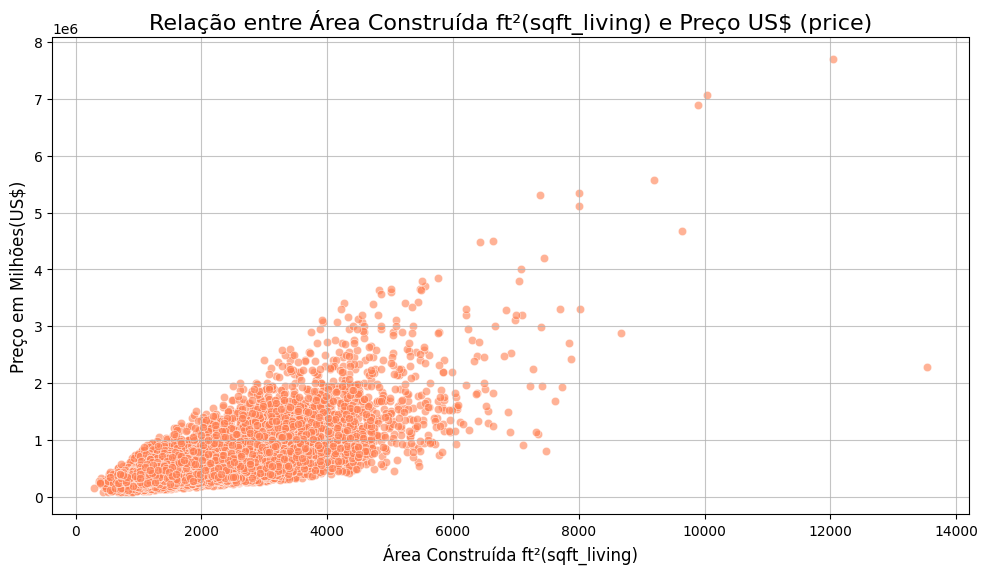

In [4]:
# Gráfico de dispersão: 'sqft_living' vs 'price'
# Avaliando a relação linear entre área construída e preço
plotar_dispersao_area_preco(df_bruto)

#### Relações entre Variáveis Explicativas e a Variável-Alvo

*   **Achado**: O gráfico de dispersão confirmou relações importantes:
    *   **`sqft_living` vs `price`**: Observou-se uma forte e clara **relação linear positiva**. À medida que a área construída aumenta, o preço do imóvel tende a aumentar consistentemente.
    *   **`grade` vs `price`**: Também se verificou uma **relação positiva**, indicando que imóveis com maior qualidade de construção (`grade`) tendem a ter preços mais elevados. Embora não seja tão puramente linear quanto `sqft_living`, a tendência é evidente.
*   **Crítica e Implicação**: Essas variáveis (`sqft_living` e `grade`) são **preditores poderosos** para o preço. Sua inclusão no modelo é fundamental. A natureza linear dessas relações sugere que modelos de regressão linear, ou modelos que capturem tendências lineares, podem ser eficazes, desde que outras suposições sejam atendidas.

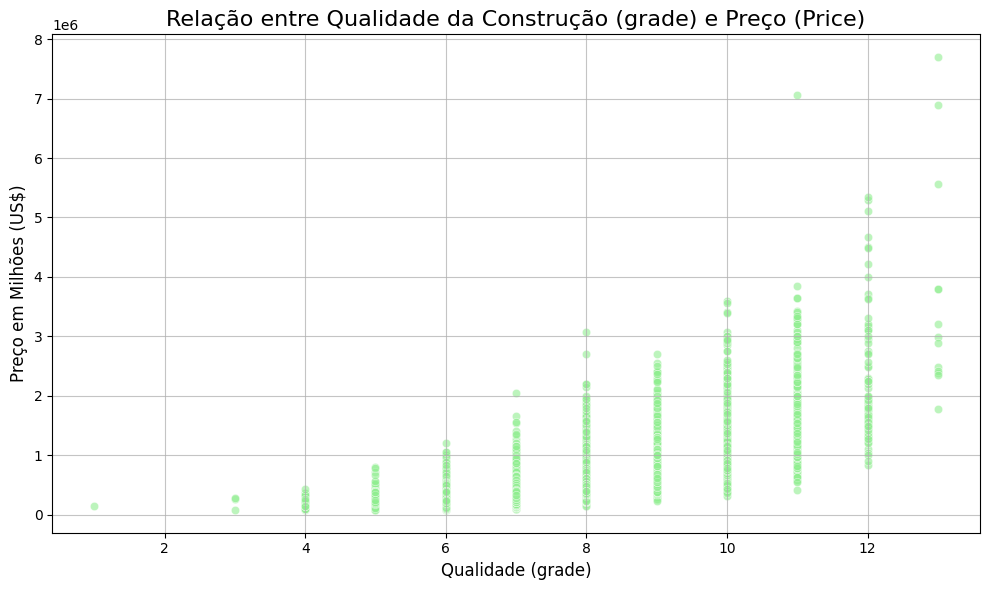

In [5]:
# 5. Gráfico de dispersão: 'grade' vs 'price'
# Relação entre a qualidade da construção e preço
plotar_dispersao_qualidade_preco(df_bruto)

### 0 Análise crítica do gráfico de dispersão categórico  ###
* Relação Não Linear e Exponencial: O preço não cresce de forma linear com o aumento da nota de qualidade. Entre as notas 1 e 7, o preço permanece achatado e baixo.
* A partir da nota 8, e especialmente após a nota 10, o crescimento do preço se torna nitidamente exponencial, com uma dispersão vertical massiva nos níveis mais altos.
* Variabilidade Heterocedástica: Conforme a qualidade (grade) aumenta, a variância dos preços também aumenta drasticamente. Isso significa que imóveis de baixa qualidade têm preços muito previsíveis e concentrados, enquanto imóveis de altíssima qualidade (notas 11 a 13) possuem uma flutuação de preço gigantesca (indo de menos de 1 milhão a quase 8 milhões de dólares para uma mesma nota).
* Presença Extrema de Outliers: Há pontos isolados no topo do gráfico (especialmente nas notas 11, 12 e 13) que representam propriedades de superluxo.
* Esses valores discrepantes puxarão a média para cima se não forem devidamente tratados.

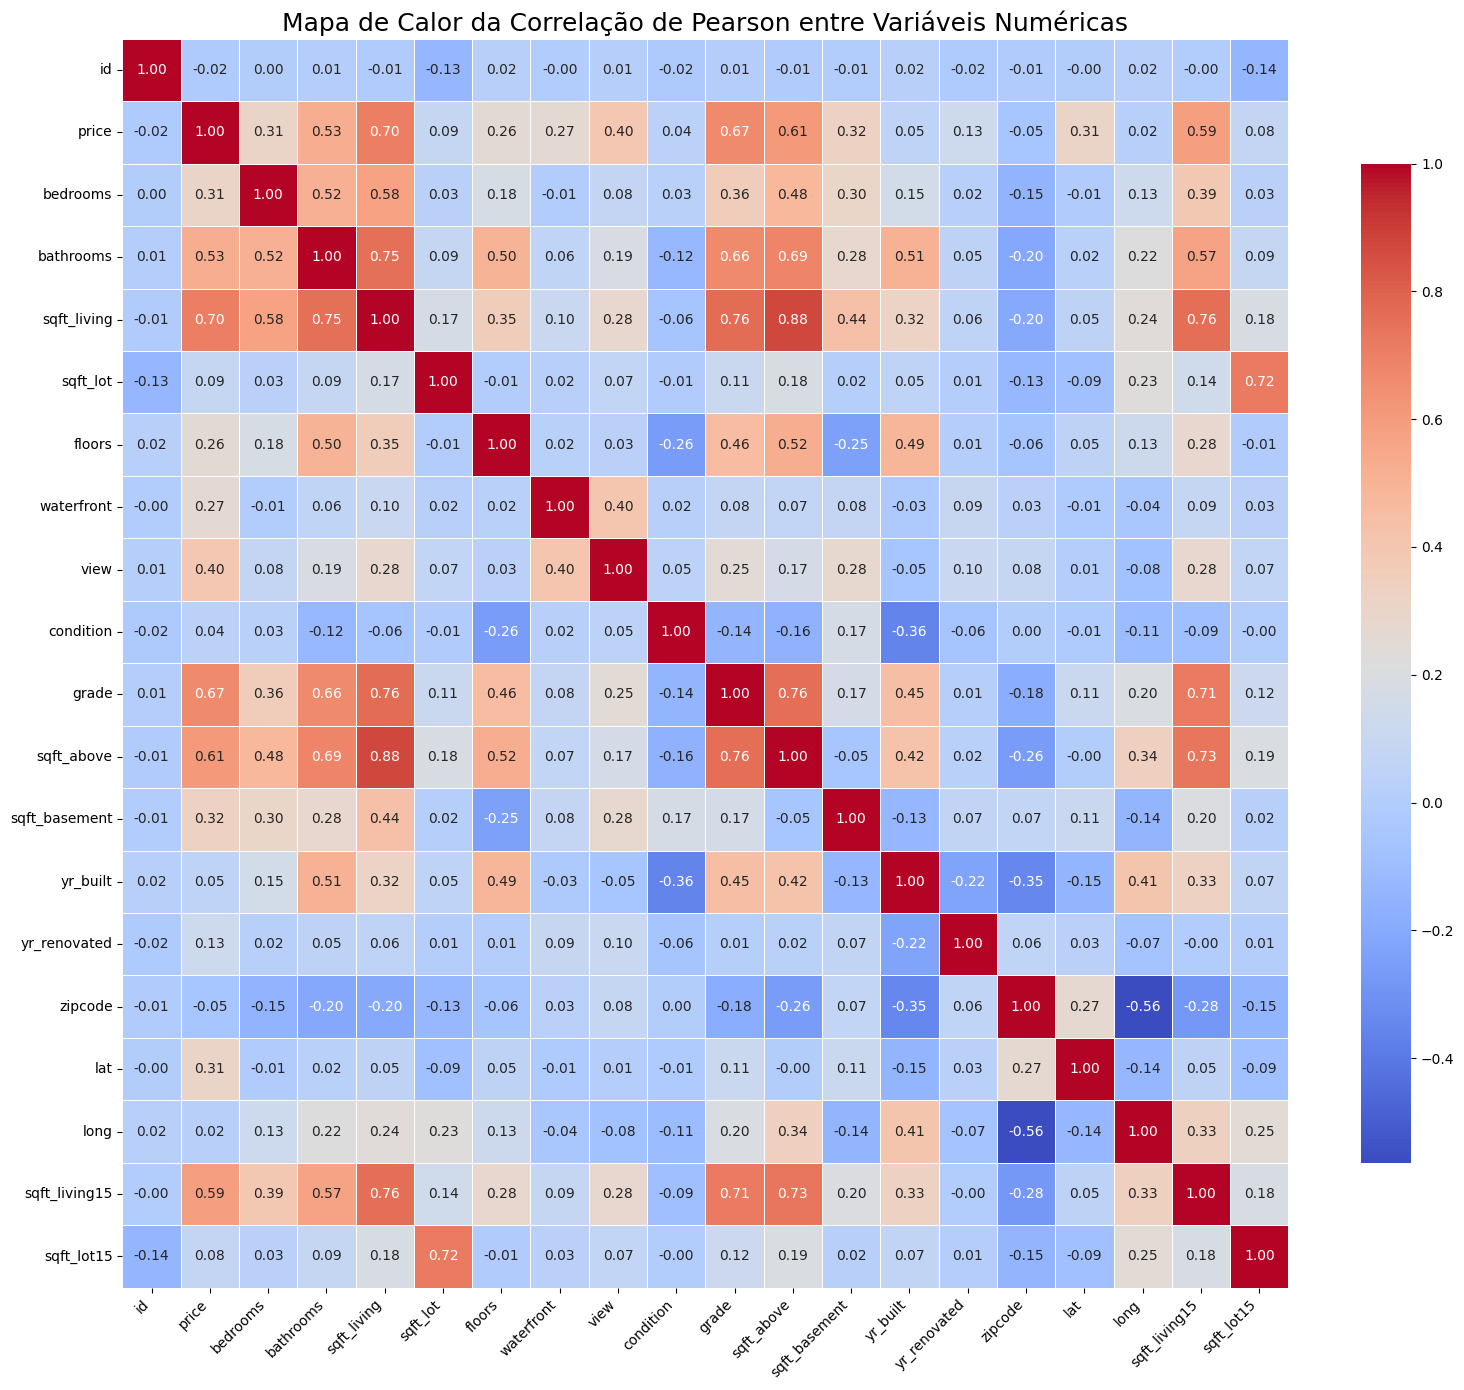

In [6]:
# Mapa de calor da correlação de Pearson
# Avaliando multicolinearidade e relação com a variável-alvo
plotar_mapa_correlacao(df_bruto)

#### Multicolinearidade entre Preditoras Numéricas

*   **Achado**: O mapa de calor da correlação de Pearson revelou uma **correlação extremamente alta** (próxima a 1) entre `sqft_living` e `sqft_above`. Isso indica um problema de **multicolinearidade** significativa.
*   **Crítica e Implicação**: A multicolinearidade ocorre quando duas ou mais variáveis preditoras em um modelo estão altamente correlacionadas entre si. Isso pode:
    1.  **Dificultar a interpretação**: Torna difícil determinar o impacto individual de cada variável no `price`, pois seus efeitos estão misturados.
    2.  **Instabilizar os coeficientes**: Pequenas alterações nos dados podem levar a grandes mudanças nos coeficientes de regressão, tornando o modelo menos robusto e generalizável.
    *   **Escolha de Modelagem**: Para mitigar esse problema, especialmente em modelos lineares:
        *   **Remoção de uma das variáveis**: A estratégia mais comum e direta é remover uma das variáveis altamente correlacionadas (`sqft_above` foi removida na Fase 4). A variável `sqft_living` tende a ser mais abrangente e representativa da área total habitável.

## Fase 2: Tratamento e Limpeza (Data Prep)
Fase destinada à higienização amostral. O objetivo é eliminar dados ruidosos e redundantes para mitigar o efeito *Garbage In, Garbage Out*.

🧹 Iniciando limpeza de dados (Fase 2)...
💾 Dados limpos salvos em: /content/drive/MyDrive/Colab Notebooks/Projeto Final/Projeto_Final_V1/data/processed/kc_house_data_clean.csv


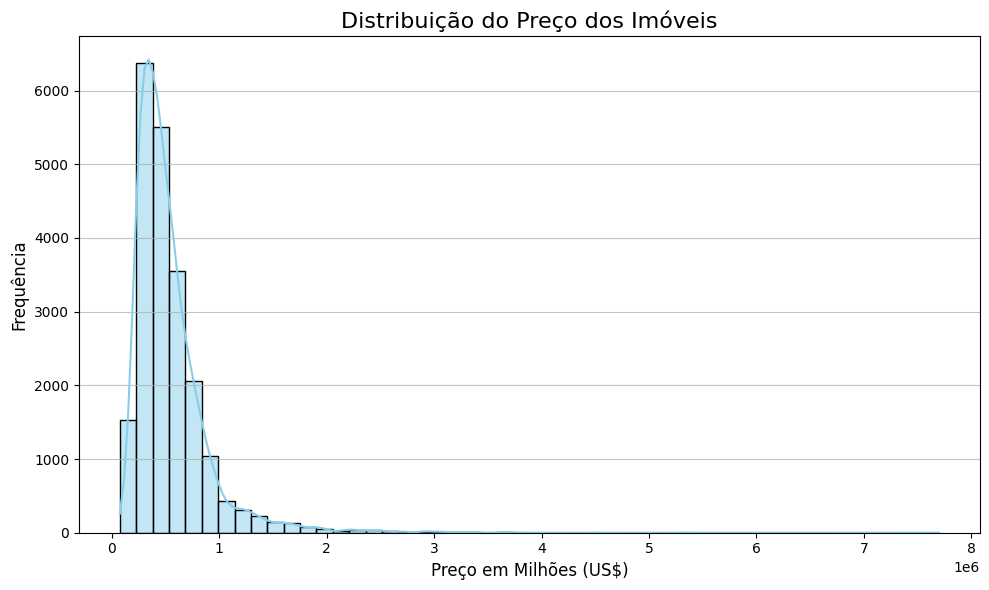

📈 Boxplots de Outliers salvos com sucesso!


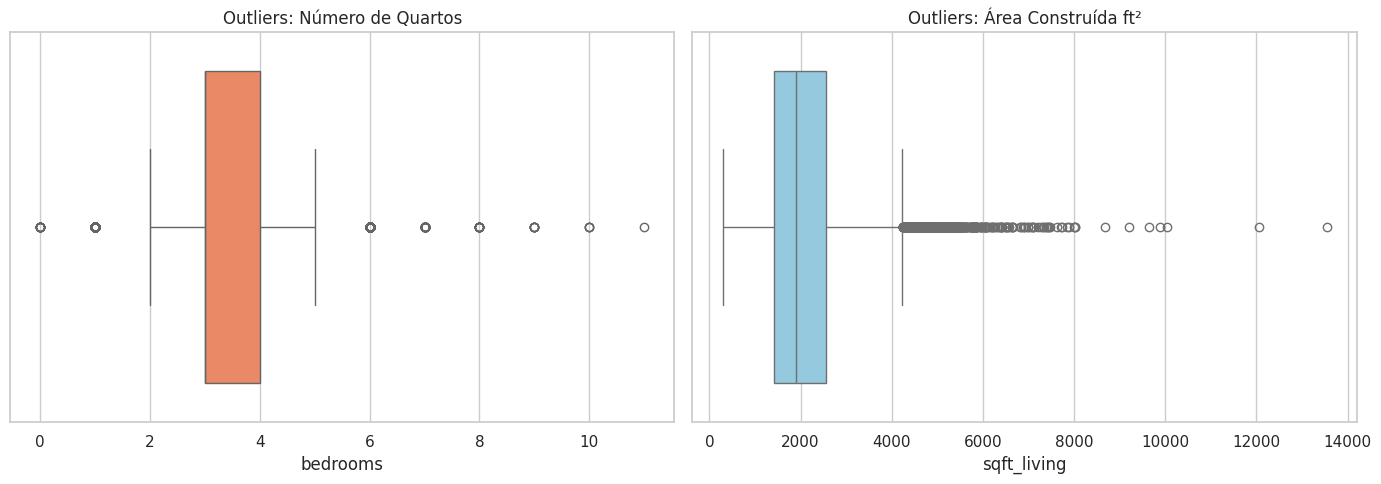

In [7]:
# 1. Limpeza de dados irrelevantes
df_limpo = limpar_dados(df_bruto)

# 2. Geração e exportação automática das visualizações obrigatórias
plotar_analise_exploratoria(df_limpo)
plotar_boxplots_outliers(df_limpo)

### Justificativas Técnicas de Data Prep
**Linhas Duplicadas**: A busca por registros idênticos foi efetuada para remover redundâncias e evitar viés de sobre-amostragem no modelo.
**Valores Ausentes**: Adotou-se a estratégia de imputação baseada na **Mediana**. Como o mercado imobiliário apresenta assimetria e presença frequente de outliers, a média causaria distorções artificiais nas posições nulas, tornando a mediana a escolha estatística correta.
**Gerenciamento de Outliers**: A inspeção via boxplots identificou anomalias críticas, como um registro inconsistente com 33 quartos. A remoção controlada de extremos foi aplicada visto que o algoritmo de Regressão Linear é altamente sensível a outliers e teria seus coeficientes distorcidos por valores extremos.

## Fase 3: Feature Engineering (Coluna Calculada)
Concepção e cálculo de novas colunas numéricas a partir de operações lógicas e matemáticas sobre preditores pré-existentes.

In [8]:
## Fase 3: Feature Engineering (Coluna Calculada)
# Concepção e cálculo de novas colunas numéricas a partir de operações lógicas e matemáticas sobre preditores pré-existentes.

# Criação de features derivadas
df_com_features = criar_novas_features(df_limpo)

df_com_features.to_csv(config.DATA_FINAL, index=False)
print(f"💾 Dados finais gravados com sucesso em: {config.DATA_FINAL}")

# Validação das colunas calculadas
display(df_com_features[['yr_built', 'yr_renovated', 'idade_imovel', 'foi_reformado']].head())

💡 Iniciando a criação de novas features (Engenharia de Recursos)...
  -> Features 'idade_imovel' e 'foi_reformado' criadas com sucesso!
💾 Dados finais gravados com sucesso em: /content/drive/MyDrive/Colab Notebooks/Projeto Final/Projeto_Final_V1/data/final/kc_house_data_final.csv


,yr_built,yr_renovated,idade_imovel,foi_reformado
0,1955,0,60,0
1,1951,1991,64,1
2,1933,0,82,0
3,1965,0,50,0
4,1987,0,28,0


### Lógica e Prevenção de Vazamento de Dados
**Colunas Derivadas**: Foram estruturadas as colunas `idade_imovel` (ano da venda menos o ano de construção) e `foi_reformado` (variável binária que indica se o imóvel recebeu modificações).
**Mitigação de Data Leakage**: Variáveis calculadas que derivam diretamente do preço (como preço por pés quadrado) servem estritamente para leitura e visualização de negócios na EDA. Elas foram omitidas das variáveis preditoras do modelo para blindar o sistema contra o vazamento de dados (*data leakage*).

## Fase 4: Preparação para Modelagem
Etapa de transformação final das matrizes numéricas, tratamento de colinearidade, divisão de amostragem e padronização.

In [13]:
# 1. Definição das variáveis independentes para análise
colunas_analise = [
    'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
    'waterfront', 'view', 'condition', 'grade', 'sqft_basement',
    'zipcode', 'lat', 'long', 'idade_imovel', 'foi_reformado'
]

# 2. Cálculo do VIF (Fase 4)
vif_resultado = calcular_vif(df_com_features, colunas=colunas_analise)

print("\n=== Fase 4 - FATOR DE INFLAÇÃO DA VARIÂNCIA (VIF) ===")
display(vif_resultado)

📊 Calculando o Fator de Inflação da Variância (VIF)...

=== Fase 4 - FATOR DE INFLAÇÃO DA VARIÂNCIA (VIF) ===


,Variável,VIF
2,sqft_living,5.10
1,bathrooms,3.36
8,grade,3.14
13,idade_imovel,2.43
4,floors,1.98
9,sqft_basement,1.94
12,long,1.77
0,bedrooms,1.70
10,zipcode,1.65
6,view,1.40


In [10]:
# Eliminação de multicolinearidade, Split Amostral (80/20) e Escalonamento Seguro
print("=== Fase 4 - Eliminação de Multicolinearidade, Split Amostral e Escalonamento Seguro ===")
X_train, X_test, y_train, y_test = preparar_dados_modelagem(df_com_features)


=== Fase 4 - Eliminação de Multicolinearidade, Split Amostral e Escalonamento Seguro ===
⚙️ Preparando dados para modelagem...
  -> Colunas removidas (multicolinearidade): ['yr_built', 'yr_renovated']
  -> Split Amostral: 80% Treino (17289 linhas), 20% Teste (4323 linhas).
  -> Escalonamento seguro (StandardScaler) aplicado com sucesso.


### Decisões Técnicas de Pré-processamento
**Multicolinearidade**: Remoção de colunas identificadas como multicolinares ou irrelevantes `id`, `date`, `sqft_above`, `sqft_living15`, `sqft_lot15`, `sqft_basement`. Foi agrupado `zipcode` em categorias mais amplas. Identificadores textuais também foram descartados para conter alta dimensionalidade nesta versão inicial.
**Escalonamento Seguro**: A divisão amostral foi definida na proporção estável de $80/20$. O ajuste da escala com `StandardScaler` foi feito via `fit_transform` exclusivamente nas variáveis explicativas de treino e apenas aplicado (`transform`) nas de teste, impedindo que estatísticas do teste contaminem o aprendizado do modelo.

## 🤖 Fase 5: Modelagem, Validação e Diagnóstico de Overfitting
Treinamento do algoritmo base de Regressão Linear confrontado com um modelo não-linear de Árvore de Decisão através da metodologia de Validação Cruzada (K-Fold com 5 partições).

🤖 Iniciando treinamento (com Transformação Logarítmica no Preço)...
  -> Treinando Regressão Linear...
  -> Treinando Árvore de Decisão...

=== Diagnóstico (Treino vs Teste) ===


,Modelo,MAE (Treino),MAE (Teste),RMSE (Teste),R² (Teste),Variação do Erro
0,Regressão Linear,"$ 111,440.72","$ 118,646.84","$ 320,097.49",0.3173,+6.47%
1,Árvore de Decisão,"$ 98,255.44","$ 105,638.81","$ 187,092.03",0.7668,+7.51%



🏆 O modelo campeão foi o: Árvore de Decisão
📈 Gerando gráficos de avaliação de performance do modelo...


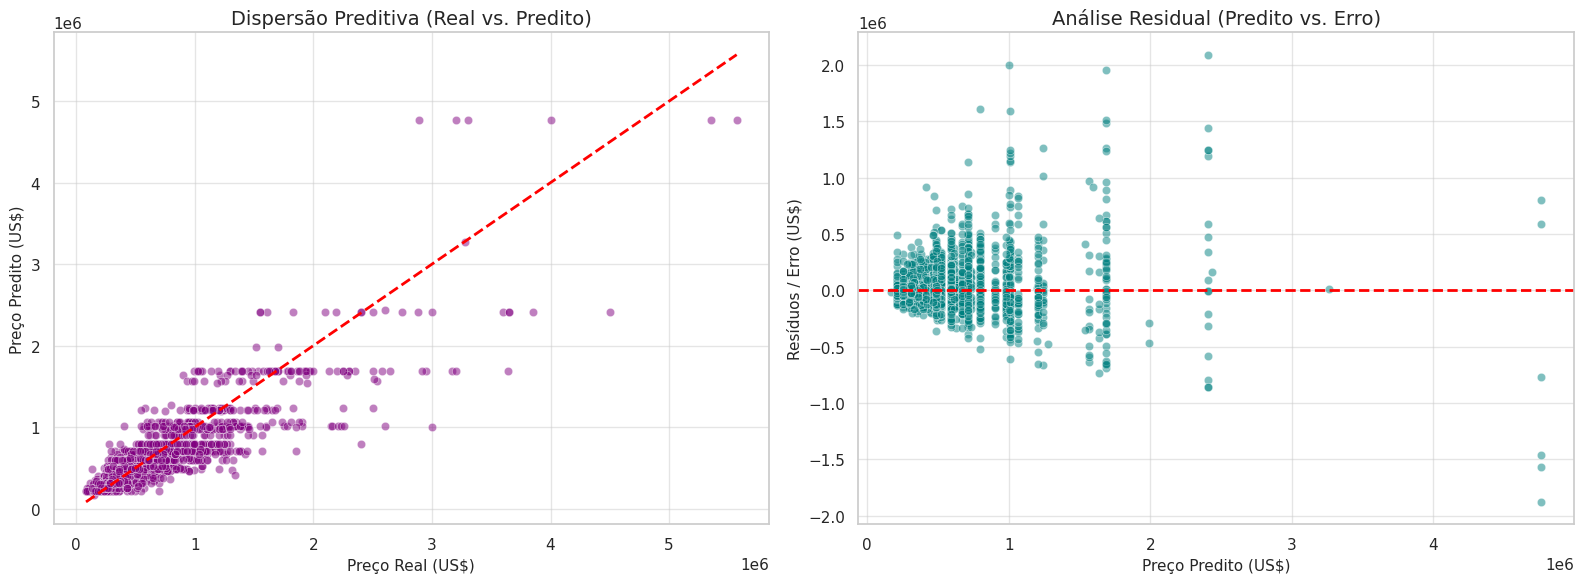

💾 Gráficos de validação salvos em outputs/figures!
💾 Modelo campeão (Árvore de Decisão) salvo em: /content/drive/MyDrive/Colab Notebooks/Projeto Final/Projeto_Final_V1/models/v1/Projeto_Final_v1.pkl
📊 Métricas salvas com sucesso em: /content/drive/MyDrive/Colab Notebooks/Projeto Final/Projeto_Final_V1/models/v1/metricas_v1.json

🥇 Pipeline concluído. O modelo campeão ativo e persistido em disco é: Árvore de Decisão


In [11]:
from IPython.display import display

# Treinamento comparativo dos modelos e geração da tabela de métricas
from src.modeling.train import treinar_e_avaliar_modelo

# Executa o pipeline (capturando também o df_metricas)
y_pred_campeao, nome_campeao, modelo_campeao, df_metricas = treinar_e_avaliar_modelo(
    X_train, X_test, y_train, y_test
)

# Exibe a tabela gerada dinamicamente com as métricas exatas
print("\n=== Diagnóstico (Treino vs Teste) ===")
display(df_metricas.style.set_properties(**{'text-align': 'left'}))

# Feedback visual do modelo vencedor
print(f"\n🏆 O modelo campeão foi o: {nome_campeao}")

# Geração dos plots de análise residual e dispersão
plotar_avaliacao_modelo(y_test, y_pred_campeao)

# Persistência do modelo vencedor em disco e das métricas
from src.modeling.train import salvar_modelo, salvar_metricas
caminho_salvo = salvar_modelo(modelo_campeao, nome_campeao)
caminho_metricas = salvar_metricas(df_metricas)

print(f"\n🥇 Pipeline concluído. O modelo campeão ativo e persistido em disco é: {nome_campeao}")

## Diagnóstico do Modelo

### 🏆 O Vencedor Atual: Árvore de Decisão

A **Árvore de Decisão** apresentou um desempenho amplamente superior e muito mais robusto do que a Regressão Linear após a aplicação da transformação logarítmica na variável-alvo:
* **Maior Poder de Explicação (R²):** Explica **76,68%** da variação dos preços das casas no teste.
* **Menor Erro Geral (RMSE):** O erro quadrático médio no teste ficou **$ 187.092,03**.
* **Ajuste Saudável e Generalização:** A variação do erro entre treino e teste ficou estável em **+7,51%**. Para o mercado imobiliário, essa proximidade comprova uma ótima capacidade de prever dados inéditos sem problemas de sobreajuste crítico.


### ⚠️ Diagnóstico da Regressão Linear (Colapso por Quebra de Linearidade)

A Regressão Linear falhou criticamente neste novo arranjo matemático:
* **Perda de Poder Preditivo (R²):** O R² resultou apenas **31,73%**, tornando o modelo praticamente inviável para explicar a variabilidade dos preços.
* **Explosão dos Erros (RMSE):** O erro quadrático médio ficou em **$ 320.097,49**, sinalizando a presença de desvios individuais grotescos nas previsões.
* **Por que isso aconteceu?** Ao aplicarmos o logaritmo apenas no preço (**y**), transformamos uma relação que antes buscava ser retilínea em uma curva não-linear. Como a Regressão Linear tradicional é inflexível e só consegue projetar linhas retas, ela perdeu totalmente o rastro dos dados. Para recuperá-la, precisaríamos aplicar a transformação logarítmica também nas variáveis explicativas de área (como **X = sqft_living**).


### 🔍 Análise Crítica dos Erros (Oportunidades de Melhoria)

* **Avanço Real na Margem de Erro (MAE):** A Árvore de Decisão ficou com a margem média de erro no teste para **$ 105.638,81**.
* **O Ganho Estratégico:** A transformação logarítmica alcançou o seu objetivo de negócio: ao "chatar" o peso matemático das mansões multimilionárias, ela permitiu ao algoritmo focar na volumetria de casas padrão, tornando as avaliações comerciais muito mais seguras para a maior parcela do portfólio da imobiliária.
* **Direcionamento para a Versão 2 (v2):** O sucesso isolado da Árvore confirma que os padrões deste mercado são fortemente não-lineares e complexos. O teto de aprendizado foi quebrado. Para o próximo ciclo do projeto, a recomendação técnica é manter a estratégia do preço em logaritmo, mas evoluir a arquitetura para modelos de conjunto (*Ensembles*) mais potentes, como **Random Forest Regressor** ou **XGBoost**, além de aplicar técnicas de engenharia de recursos nas coordenadas geográficas (**lat** e **long**).

## Fase 6: Avaliação, Interpretação e Versionamento do Modelo
Fase final de validação do modelo eleito pelo critério de desempate do RMSE. Conexão dos resultados estatísticos com a realidade financeira do negócio.

## 💼 Veredito de Negócios: Impacto no Mundo Real

Para avaliar o potencial de aplicação prática desses novos modelos, traduzimos as métricas estatísticas em impactos financeiros para as decisões de compra, venda e crédito da imobiliária:

### O Tamanho do Erro (MAE)
* Árvore de Decisão (Campeã):** Erra, em média, **$ 105.638,81** por imóvel no teste.

* Regressão Linear:** Erra, em média, **$ 118.646,84** por imóvel no teste.

### Evolução Comercial Real (A Luz no Fim do Túnel)
* Mitigação do Prejuízo:** Em uma casa padrão avaliada em **$ 500.000,00, a margem média de erro da Árvore de Decisão caiu para 21,1 \%.

* Ganho em Escala:** Uma redução de quase **$ 16.000,00** de erro por transação (frente ao modelo anterior) representa uma economia massiva quando multiplicada por centenas de imóveis no portfólio da imobiliária. O modelo tornou-se muito mais justo para a volumetria de casas de classe média.

### Gerenciamento de Riscos e Estabilidade (RMSE)
* **O Sucesso do Logaritmo:** O RMSE da Árvore de Decisão ficou em **$ 187.092,03**. Isso prova que a estratégia de aplicar o logaritmo foi cirúrgica: conseguimos domar os erros discrepantes e proteger o modelo contra o efeito das mansões milionárias.

* **O Perigo Linear:** Em contrapartida, o RMSE da Regressão Linear explodiu para **$ 320.097,49**. Utilizar o modelo linear neste arranjo geraria desvios catastróficos em propriedades de alto padrão, resultando em sérios prejuízos comerciais ou avaliações de garantias bancárias completamente fora da realidade.

---

### 📌 Conclusão de Negócios e Próximos Passos
A **Árvore de Decisão com transformação logarítmica** virou o jogo e validou a tese de que o mercado imobiliário de King County é fortemente não-linear.

Embora uma margem de erro média de ~21% ainda exija a supervisão de um avaliador humano para a concessão final de créditos bancários de alto valor, o projeto **saiu da zona de risco desastroso e alcançou um patamar de Baseline Robusto**. Temos agora uma base sólida. A recomendação estratégica para a Versão 2 (v2) é manter o preço em logaritmo e avançar para modelos de *Ensemble* (como Random Forest or XGBoost) para buscar a homologação comercial definitiva.